# **Initial Importing**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

firstFilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_1.csv"
secondFilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_2.csv"
filePaths = [firstFilePath, secondFilePath]
dfList = [pd.read_csv(file) for file in filePaths]
dfMerged = pd.concat(dfList, ignore_index=True)
outputPath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_merged.csv"
dfMerged.to_csv(outputPath)


---
# **Making Data Labled**  
### I self labeled the data so that it is an accurate labeling of whether it is a closure, reopening and so on. This was done outside of this notebook and overall project folder as it was a tedious task done with first self labeling in Excel and then handing the work to a GPT Model with adequet prompt engineering.

In [4]:
labeledfilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_labeled.csv"
df = pd.read_csv(labeledfilePath)
print(df.columns)
# The new columns are the last few

Index(['Unnamed: 0', 'facebookId', 'facebookUrl', 'feedbackId', 'likes',
       'postId', 'text', 'timestamp', 'user/id', 'user/name',
       'user/profilePic', 'user/profileUrl', 'viewsCount', 'collaborators',
       'link', 'is_eb', 'is_wb', 'is_closure', 'is_reopening', 'is_placing',
       'is_lifted'],
      dtype='str')


---
# **Data Fixing** 
### The dates were in the wrong timezone, so I converted them to accurately match the facebook post. Now we can actuall merge this with weather.

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit = 's', utc = True)
df["timestamp"] = df["timestamp"].dt.tz_convert("US/Pacific")


---
# **Starting EDA**

### First we will look into the distribution of the tweets with the different labels we just created. We can notice imbalances between different categories, especially is placing and is lifted.

Text(0, 0.5, 'Number of Tweets')

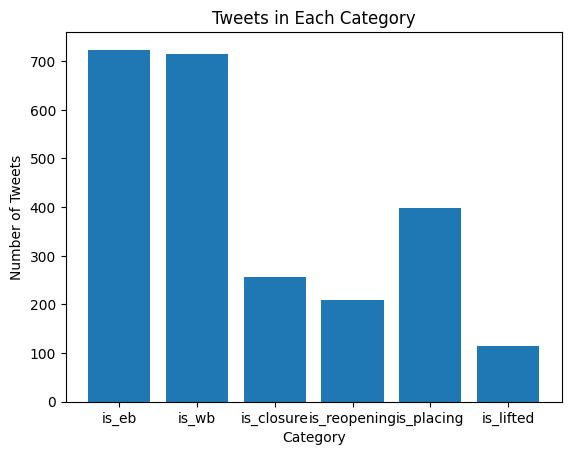

In [26]:
counts = df[["is_eb", "is_wb", "is_closure", "is_reopening", "is_placing", "is_lifted"]].sum()

plt.bar(counts.index, counts.values)
plt.title("Tweets in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Tweets")

In [28]:
df["timestamp"]

0      2026-02-25 16:09:16-08:00
1      2026-02-24 19:16:49-08:00
2      2026-02-21 11:13:40-08:00
3      2026-02-20 12:21:31-08:00
4      2026-02-20 11:51:24-08:00
                  ...           
2991   2017-02-21 23:17:22-08:00
2992   2017-02-21 22:12:23-08:00
2993   2017-02-21 21:25:26-08:00
2994   2017-02-21 18:56:34-08:00
2995   2017-02-21 17:37:18-08:00
Name: timestamp, Length: 2996, dtype: datetime64[s, US/Pacific]